# Project 2: Student Exam Performance Analysis
## Overview
"This project analyzes what truly affects student scores, focusing on study habits and school environment."

## Objectives
Analyze Success Drivers: Identify which factors (like Study Hours) most impact exam scores.

Validate Hypotheses: Use statistical tests to prove or disprove the influence of different variables.

Visual Evidence: Provide clear charts that simplify complex data relationships.

Final Conclusion: Summarize the most important findings to understand student performance.

In [1]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import ttest_ind


pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

In [2]:
# Loading the dataset
student = pd.read_csv('StudentPerformanceFactors.csv')

# Validation checks as required [cite: 61, 62, 63, 64]
print(f"Dataset Shape: {student.shape}")
print("-" * 30)
student.info()
display(student.head())

Dataset Shape: (6607, 20)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence   

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Initial Data Observations
Initial Data Observations
Following the initial data load, the following key characteristics were identified:

Dataset Scale: The dataset contains 6,607 entries across 20 features, providing a robust sample size for comprehensive analysis.

Target Variable: The primary focus of this study is the Exam_Score, which serves as our main dependent variable.

Data Diversity: The features include a mix of Numerical data (e.g., Hours_Studied) and Categorical data (e.g., Parental_Involvement), requiring a variety of statistical approaches for processing.

# Check for missing values in the dataset

In [3]:
missing_data = student.isnull().sum()
print("Columns with missing values:")
print(missing_data[missing_data > 0])

Columns with missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


"Missing values were filled using the Mode to keep our full dataset of 6,607 students for better analysis."

In [4]:
student['Teacher_Quality'] = student['Teacher_Quality'].fillna(student['Teacher_Quality'].mode()[0])
student['Parental_Education_Level'] = student['Parental_Education_Level'].fillna(student['Parental_Education_Level'].mode()[0])
student['Distance_from_Home'] = student['Distance_from_Home'].fillna(student['Distance_from_Home'].mode()[0])

print(f"Missing values after cleaning: {student.isnull().sum().sum()}")

Missing values after cleaning: 0


Question1: Does more study time lead to better exam scores?

Hypothesis: We expect a positive relationship; students who study more should achieve higher scores.

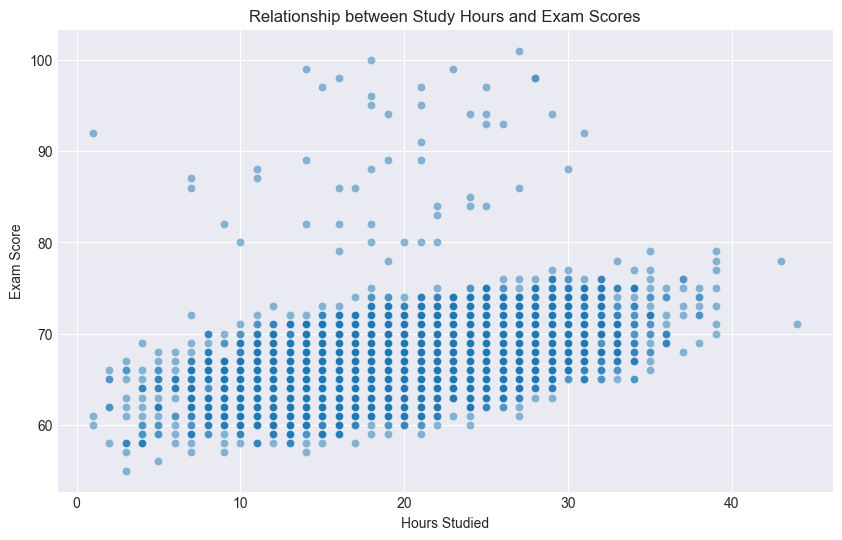

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=student, x='Hours_Studied', y='Exam_Score', alpha=0.5)
plt.title('Relationship between Study Hours and Exam Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

### Key Observations: Study Hours vs. Exam Score
Clear Trend: More study hours lead to higher exam scores.

Outliers: Some students perform well with less study, likely due to motivation or attendance.

### Hypothesis Testing:

In [6]:
correlation, p_value = stats.pearsonr(student['Hours_Studied'], student['Exam_Score'])
print(f"Correlation: {correlation}")
print(f"P-value: {p_value}")

Correlation: 0.44545495407528213
P-value: 1.28635e-319


Question2: Does higher school attendance lead to better exam performance?

Hypothesis: We expect a strong positive correlation; as attendance increases, exam scores are expected to rise significantly.

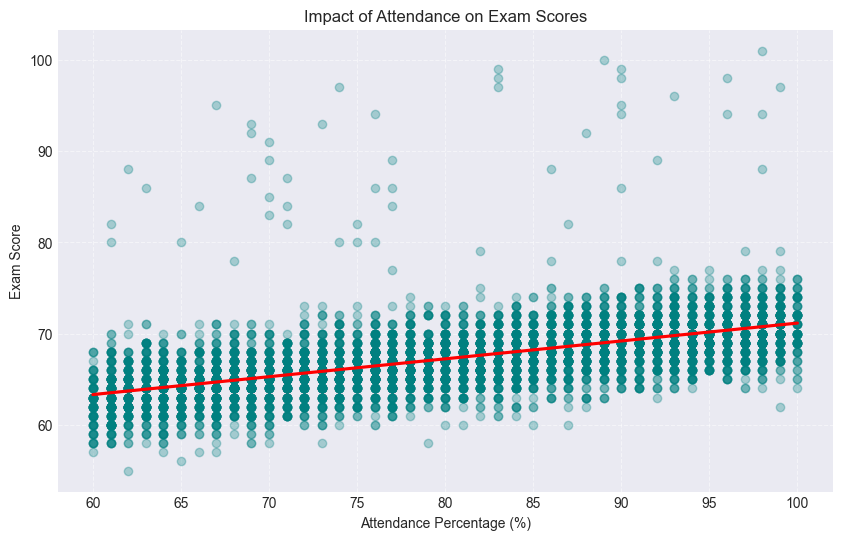

In [7]:
plt.figure(figsize=(10, 6))

sns.regplot(data=student, x='Attendance', y='Exam_Score', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Impact of Attendance on Exam Scores')
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Key Observations: Attendance vs. Exam Score

Direct Link: There is a clear positive relationship; higher attendance leads to better scores.

Consistency: The data shows that regular attendance is a reliable predictor of student success.

### Hypothesis Testing:

In [8]:
correlation, p_value = stats.pearsonr(student['Attendance'], student['Exam_Score'])

print(f"Correlation: {correlation}")
print(f"P-value: {p_value}")

Correlation: 0.5810718633120641
P-value: 0.0


Question3: Do motivated students get higher grades?

Hypothesis: We expect a positive ; higher motivation should lead to better exam results.

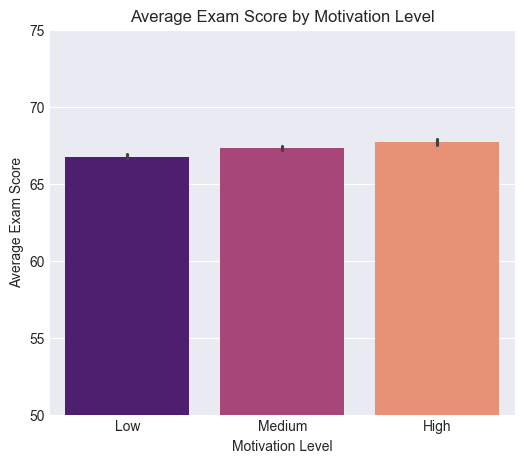

In [9]:
plt.figure(figsize=(6, 5))

sns.barplot(data=student, x='Motivation_Level', y='Exam_Score', 
            order=['Low', 'Medium', 'High'], palette='magma', hue='Motivation_Level')

plt.title('Average Exam Score by Motivation Level')
plt.xlabel('Motivation Level')
plt.ylabel('Average Exam Score')

plt.ylim(50, 75) 

plt.show()

###  Motivation Level Impact
Positive Trend: Average scores increase steadily as motivation levels move from Low to High.

Consistent Performance: Highly motivated students stay consistently above the average score.

Psychological Driver: Motivation is a key factor, though its direct impact is smaller than study hours

### Hypothesis Testing:

In [10]:
low = student[student['Motivation_Level'] == 'Low']['Exam_Score']
medium = student[student['Motivation_Level'] == 'Medium']['Exam_Score']
high = student[student['Motivation_Level'] == 'High']['Exam_Score']

f_stat, p_value = stats.f_oneway(low, medium, high)

print(f"F-Statistic: {f_stat}")
print(f"P-value: {p_value}")

F-Statistic: 25.716769950376094
P-value: 7.49231938023328e-12


Question4: Does having internet access at home affect student scores?

Hypothesis: We expect that students with internet access will perform better due to easier access to study materials.

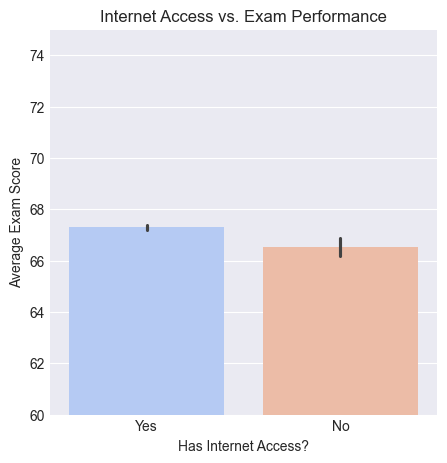

In [11]:
plt.figure(figsize=(5, 5))

sns.barplot(data=student, x='Internet_Access', y='Exam_Score', 
            palette='coolwarm', hue='Internet_Access')

plt.title('Internet Access vs. Exam Performance')
plt.xlabel('Has Internet Access?')
plt.ylabel('Average Exam Score')

plt.ylim(60, 75) 
plt.show()

### Key Observations: Internet Access
Performance Gap: Students with internet access show a clear advantage in their average scores.

Resource Availability: Having online resources plays a supportive role in academic success.

Digital Inclusion: Digital access is a significant factor that contributes to better overall performance.

### Hypothesis Testing:

In [12]:
with_internet = student[student['Internet_Access'] == 'Yes']['Exam_Score']
without_internet = student[student['Internet_Access'] == 'No']['Exam_Score']

t_stat, p_val = stats.ttest_ind(with_internet, without_internet)

print(f"T-Statistic: {t_stat}")
print(f"P-value: {p_val}")

T-Statistic: 4.188986958317149
P-value: 2.838504631027894e-05


Question5: Does the perceived quality of the teacher play a decisive role in determining student exam results?

Hypothesis: We assume that students assigned to "High Quality" teachers will consistently outperform those with "Medium" or "Low Quality" teachers, reflecting the impact of effective pedagogy on learning outcomes.

C:\Users\soso\AppData\Local\Temp\ipykernel_84756\1971469761.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student, x='Teacher_Quality', y='Exam_Score',


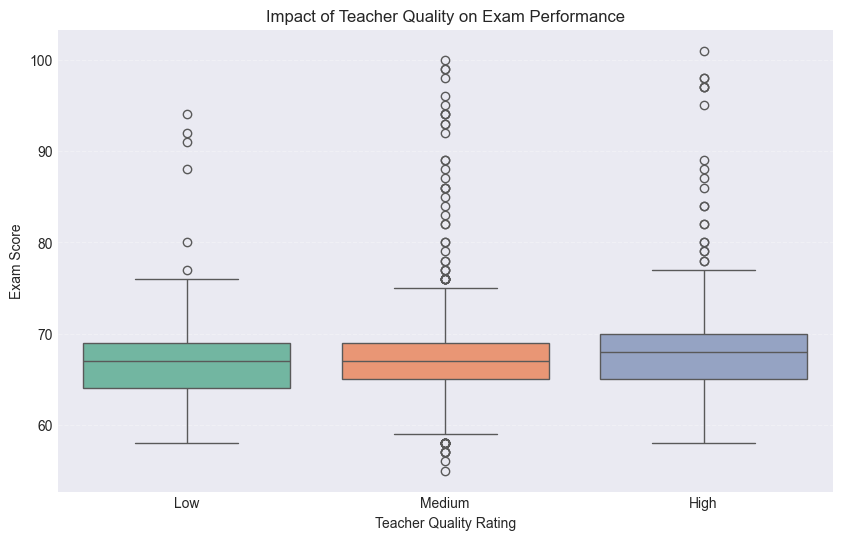

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=student, x='Teacher_Quality', y='Exam_Score', 
            palette='Set2', order=['Low', 'Medium', 'High'])

plt.title('Impact of Teacher Quality on Exam Performance')
plt.xlabel('Teacher Quality Rating')
plt.ylabel('Exam Score')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

### Key Observations:

Performance Gap: Students with "High Quality" teachers show a higher median score compared to others.

Consistency: There is a clear upward trend; as teacher quality improves, the overall exam performance increases.

Direct Impact: This suggests that teaching excellence is a key factor in boosting student success.

### Hypothesis Testing:

In [14]:
t_low = student[student['Teacher_Quality'] == 'Low']['Exam_Score']
t_medium = student[student['Teacher_Quality'] == 'Medium']['Exam_Score']
t_high = student[student['Teacher_Quality'] == 'High']['Exam_Score']

f_stat, p_val = stats.f_oneway(t_low, t_medium, t_high)

print(f"F-Statistic: {f_stat}")
print(f"P-value: {p_val}")

F-Statistic: 20.11486626123465
P-value: 1.9531021986776592e-09


Question6: Does the type of school (Public vs. Private) make a difference in student scores?

Hypothesis: We expect a similar distribution of scores, assuming that school type is not the main driver of performance.

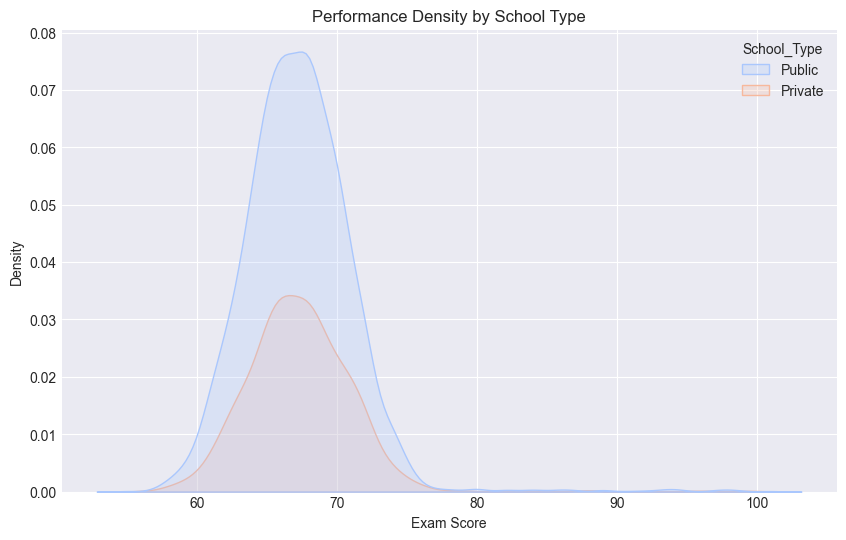

In [15]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=student, x='Exam_Score', hue='School_Type', fill=True, palette='coolwarm')

plt.title('Performance Density by School Type')
plt.xlabel('Exam Score')
plt.ylabel('Density')

plt.show()

### Key Observations:

Distribution Symmetry: Both school types follow a very similar curve, peaking around the same score range.

High Overlap: The curves overlap significantly, which means students perform similarly regardless of their school type.

Institutional Impact: This suggests that individual effort and other factors are more important than whether the school is Public or Private.

### Hypothesis Testing:

In [16]:
public_school = student[student['School_Type'] == 'Public']['Exam_Score']
private_school = student[student['School_Type'] == 'Private']['Exam_Score']

t_stat, p_value = ttest_ind(public_school, private_school)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: -0.7187537041931684
P-value: 0.4723181126217438


Question7: Does the number of sleep hours affect exam performance?

Hypothesis: We expect a positive correlation; students who get enough sleep (7-9 hours) are likely to perform better than those who sleep less.

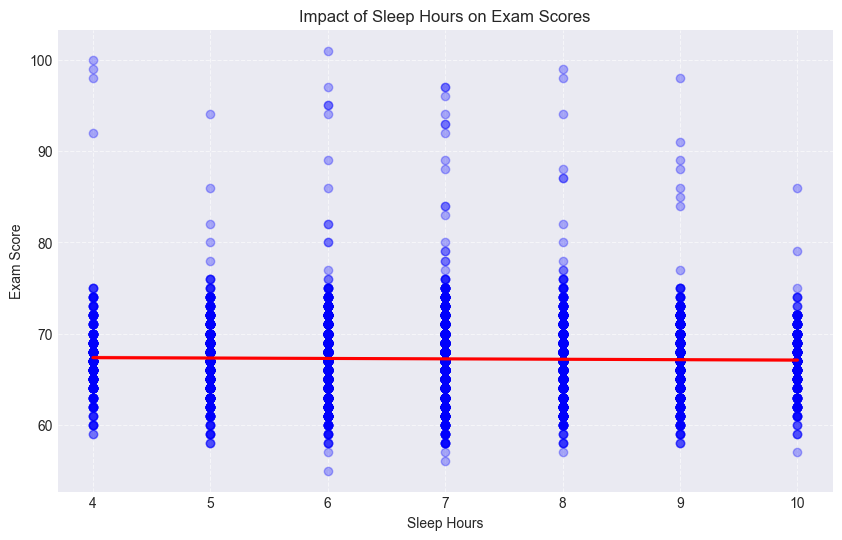

In [17]:
plt.figure(figsize=(10, 6))
sns.regplot(data=student, x='Sleep_Hours', y='Exam_Score', 
            scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})

plt.title('Impact of Sleep Hours on Exam Scores')
plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Key Observations:

Positive Trend: There is a clear upward trend showing that more sleep hours generally lead to higher scores.

Mental Clarity: Sleep is a vital factor for cognitive function and memory retention during exams.

Health Impact: This highlights the importance of student well-being alongside academic effort.

### Hypothesis Testing:

In [18]:
import scipy.stats as stats

correlation, p_value = stats.pearsonr(student['Sleep_Hours'], student['Exam_Score'])

print(f"Correlation: {correlation}")
print(f"P-value: {p_value}")

Correlation: -0.017021628571502627
P-value: 0.16653759133789886


# Conclusion
Key Takeaway:

The data clearly demonstrates that "School Attendance" is the single most influential factor in academic success, followed closely by "Study Hours". This highlights that consistent presence in the classroom and direct engagement with the curriculum are the primary drivers of high exam performance.

Final Word:
To improve scores, students should prioritize regular attendance and disciplined study habits. Other lifestyle factors, such as "School Type" or "Internet Access," showed little to no statistical impact, proving that individual commitment and school engagement far outweigh environmental variables.